# Trabajo Final de Machine Learning - Ejercicio 1
## Regresion: resistencia a la compresion del hormigon

**Grupo:** F
**Integrantes:**
- Alexis Gonzalez
- Luis Morales
- Alexia Orce
- Georgina Sicco
- Emiliano Prockoff

Este notebook compara tres algoritmos supervisados para predecir la resistencia del hormigon en MPa. Incluye metadata, EDA, preparacion, entrenamiento, evaluacion e interpretacion.

## 1. Metadata y planteamiento

El dataset de UCI contiene 1.030 mezclas de hormigon, ocho variables predictoras cuantitativas y la resistencia de compresion como variable objetivo. Las cantidades de componentes estan expresadas en kg/m3, la edad en dias y la salida en MPa.

La pregunta es: **dada una mezcla y su edad, que resistencia de compresion podemos estimar?**

## Contexto del rubro: construccion y materiales

El hormigon es uno de los materiales mas utilizados en obras como viviendas, puentes, edificios y pavimentos. Se fabrica combinando cemento, agua, agregados y, en algunos casos, otros componentes que modifican su comportamiento.

Una propiedad fundamental es la **resistencia a la compresion**: indica cuanta carga puede soportar el material cuando se lo comprime. Se expresa en MPa y normalmente se determina mediante ensayos de laboratorio realizados sobre muestras de una mezcla.

La resistencia depende de la proporcion de los ingredientes y del tiempo de curado. En general, la edad permite que el hormigon desarrolle resistencia, mientras que la cantidad de agua, cemento y aditivos influye en la estructura final del material. La relacion no es completamente simple: una mezcla con mas cantidad de un ingrediente no necesariamente es mejor si se desbalancean los demas.

En este contexto, un modelo predictivo puede ayudar a estimar rapidamente la resistencia esperada de una mezcla y apoyar el diseño inicial o el control de calidad. No reemplaza los ensayos de laboratorio ni la validacion de un profesional: funciona como una herramienta de apoyo para comparar alternativas y detectar comportamientos inusuales.

In [1]:
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid', palette='deep')
RANDOM_STATE = 42

In [2]:
DATA_PATH = Path('datasets/Concrete_Data.xls')
if not DATA_PATH.exists():
    raise FileNotFoundError(f'No se encontro el dataset: {DATA_PATH.resolve()}')

df = pd.read_excel(DATA_PATH)
df.columns = ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_aggregate', 'fine_aggregate', 'age_days', 'strength_mpa']
print(f'Dimensiones: {df.shape}')
display(df.head())

Dimensiones: (1030, 9)


,cement,slag,fly_ash,water,superplasticizer,coarse_aggregate,fine_aggregate,age_days,strength_mpa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


,count,mean,std,min,25%,50%,75%,max
cement,1030.0,281.165631,104.507142,102.000000,192.375000,272.900000,350.000000,540.000000
slag,1030.0,73.895485,86.279104,0.000000,0.000000,22.000000,142.950000,359.400000
fly_ash,1030.0,54.187136,63.996469,0.000000,0.000000,0.000000,118.270000,200.100000
water,1030.0,181.566359,21.355567,121.750000,164.900000,185.000000,192.000000,247.000000
superplasticizer,1030.0,6.203112,5.973492,0.000000,0.000000,6.350000,10.160000,32.200000
coarse_aggregate,1030.0,972.918592,77.753818,801.000000,932.000000,968.000000,1029.400000,1145.000000
fine_aggregate,1030.0,773.578883,80.175427,594.000000,730.950000,779.510000,824.000000,992.600000
age_days,1030.0,45.662136,63.169912,1.000000,7.000000,28.000000,56.000000,365.000000
strength_mpa,1030.0,35.817836,16.705679,2.331808,23.707115,34.442774,46.136287,82.599225


Valores faltantes: 0


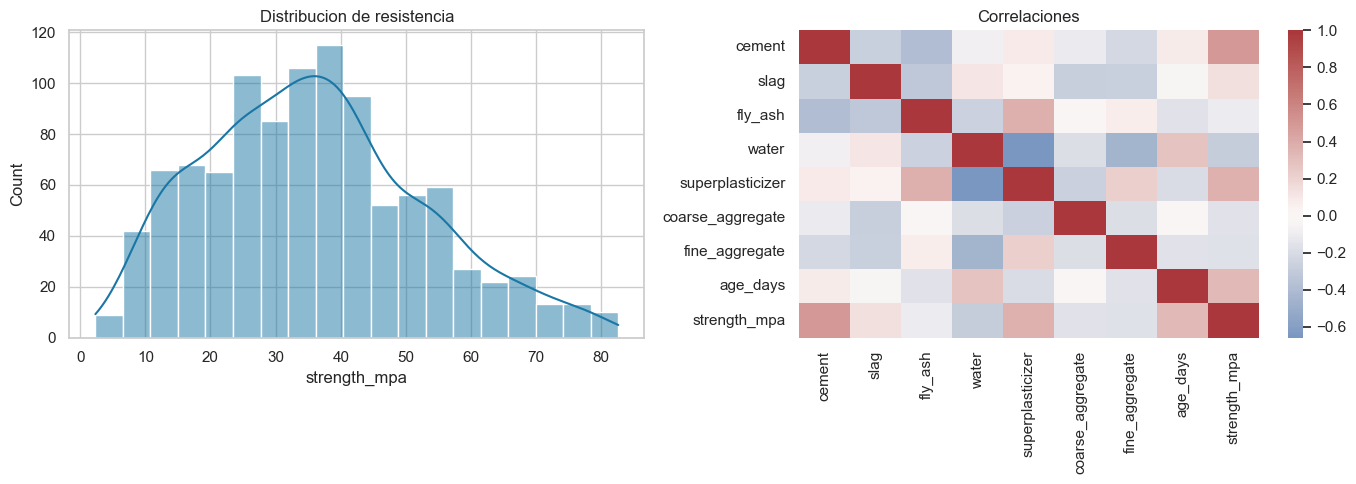

In [3]:
display(df.describe().T)
print('Valores faltantes:', df.isna().sum().sum())
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['strength_mpa'], kde=True, ax=axes[0], color='#1976a5')
axes[0].set_title('Distribucion de resistencia')
sns.heatmap(df.corr(numeric_only=True), cmap='vlag', center=0, ax=axes[1])
axes[1].set_title('Correlaciones')
plt.tight_layout()
plt.show()

### Hallazgos de los gráficos

- **Distribución de la resistencia:** la mayor parte de las observaciones se concentra en valores intermedios, alrededor de 20 a 50 MPa. La distribución presenta una ligera cola hacia resistencias altas: la media es 35,82 MPa y el máximo alcanza 82,60 MPa.
- **Mapa de correlaciones:** la resistencia se relaciona positivamente sobre todo con el contenido de cemento y con la edad, mientras que el agua presenta una asociación negativa. Esto sugiere que una mayor cantidad de cemento y un mayor tiempo de curado suelen acompañarse de más resistencia, aunque las correlaciones no prueban causalidad y no capturan relaciones no lineales.

## 2. Analisis de las variables predictoras

Las variables predictoras son los ocho atributos que utilizaremos para estimar la resistencia: los siete componentes de la mezcla y la edad del hormigon. En esta etapa analizamos su distribucion, sus relaciones con la resistencia y posibles diferencias de escala.

- Los histogramas muestran los valores frecuentes y permiten detectar asimetrias.
- Los diagramas de dispersion muestran si existe una relacion visible entre cada predictor y la resistencia.
- La matriz de correlaciones resume relaciones lineales; una correlacion alta no implica causalidad.

Estos graficos orientan el modelado, pero no reemplazan la comparacion objetiva de los modelos mediante las metricas.

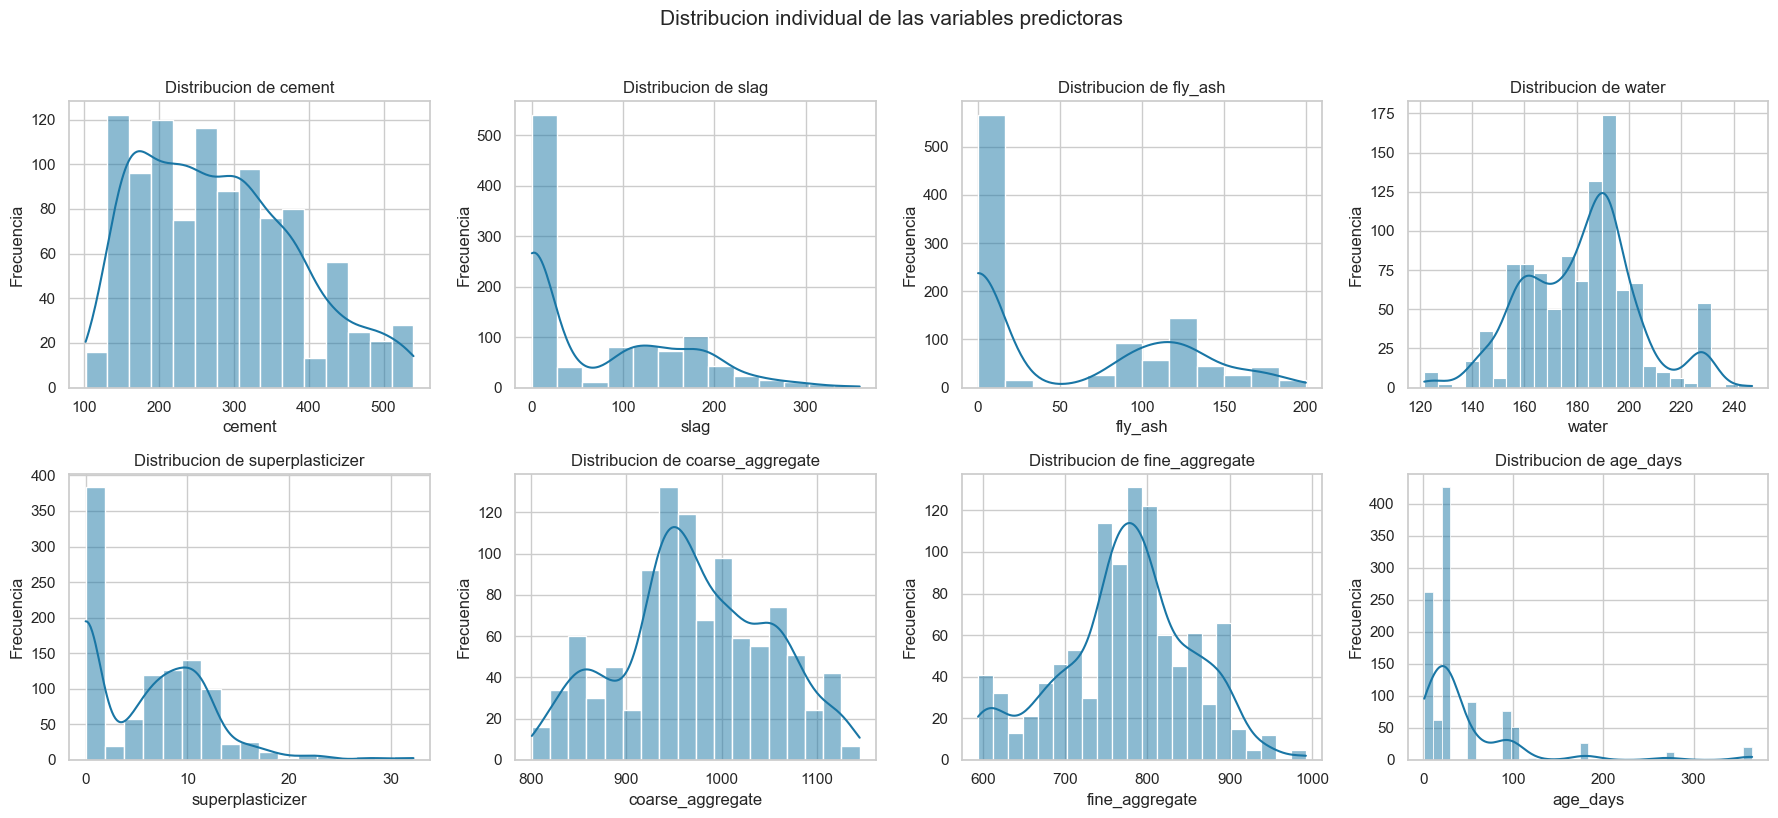

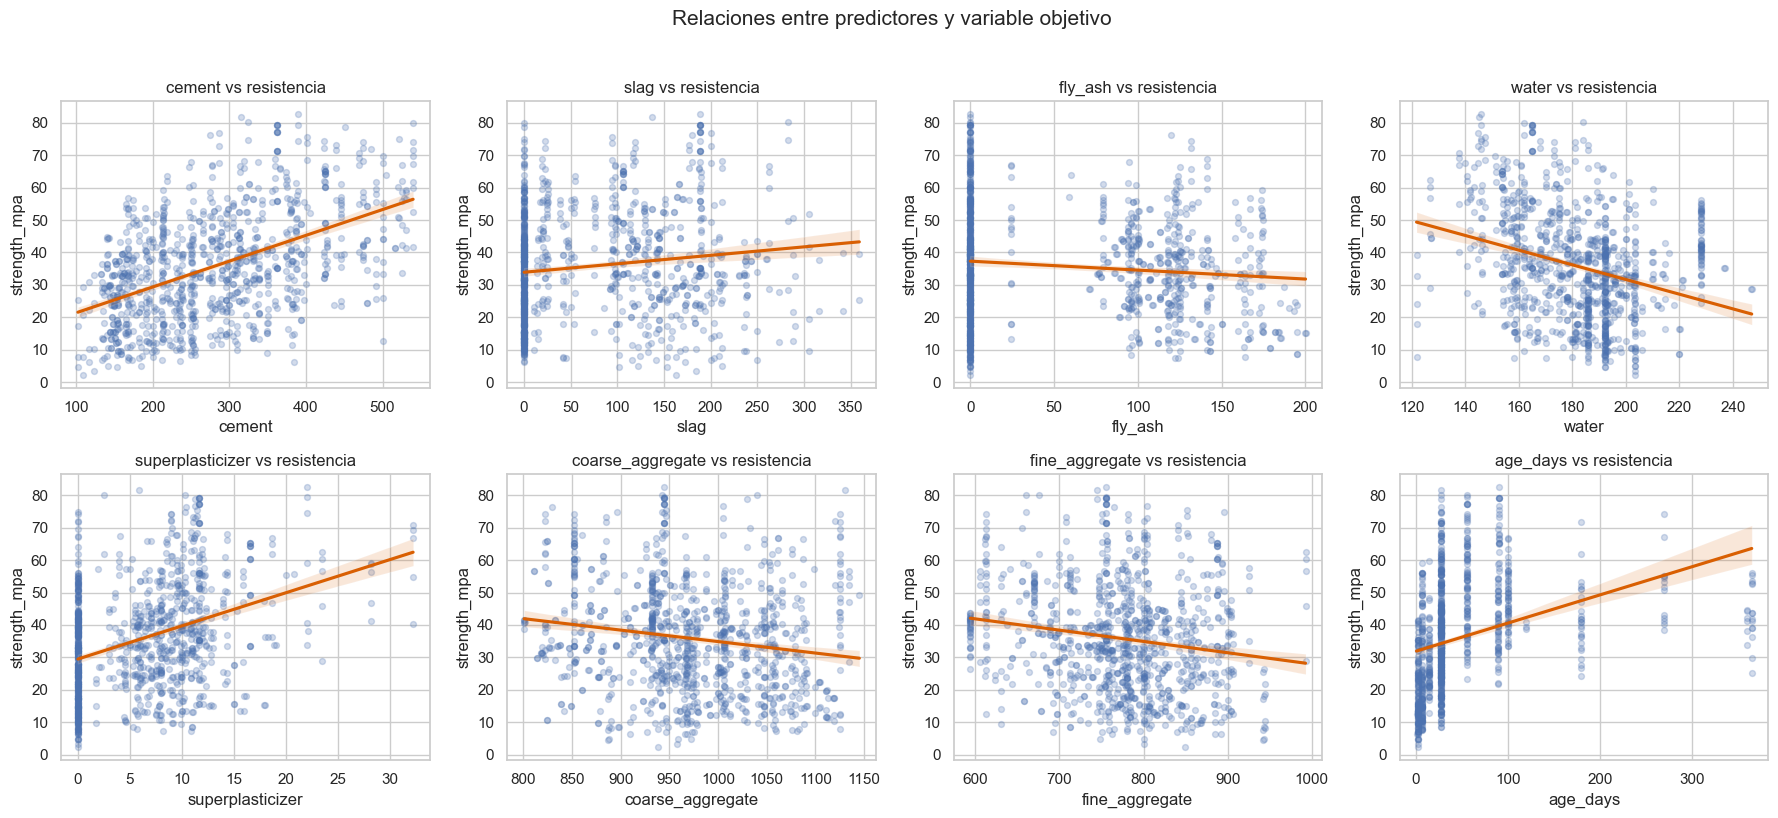

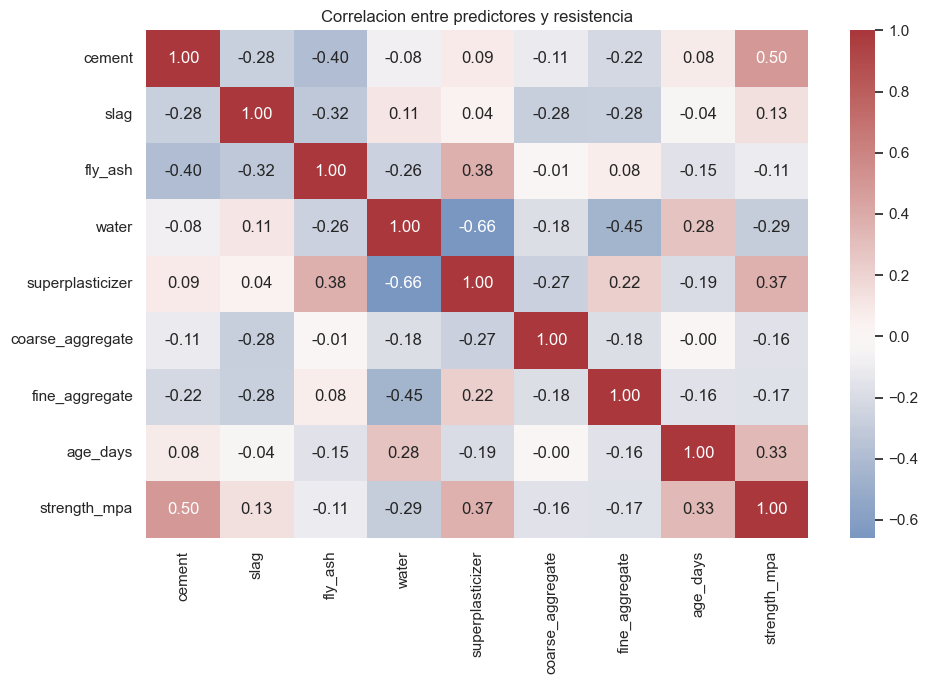

In [4]:
predictor_cols = [column for column in df.columns if column != 'strength_mpa']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, column in zip(axes.ravel(), predictor_cols):
    sns.histplot(data=df, x=column, kde=True, ax=ax, color='#1976a5')
    ax.set_title(f'Distribucion de {column}')
    ax.set_xlabel(column)
    ax.set_ylabel('Frecuencia')
plt.suptitle('Distribucion individual de las variables predictoras', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
for ax, column in zip(axes.ravel(), predictor_cols):
    sns.regplot(data=df, x=column, y='strength_mpa', ax=ax, scatter_kws={'alpha': 0.25, 's': 18}, line_kws={'color': '#d95f02'})
    ax.set_title(f'{column} vs resistencia')
plt.suptitle('Relaciones entre predictores y variable objetivo', y=1.02, fontsize=15)
plt.tight_layout()
plt.show()

predictor_corr = df[predictor_cols + ['strength_mpa']].corr()
plt.figure(figsize=(10, 7))
sns.heatmap(predictor_corr, annot=True, fmt='.2f', cmap='vlag', center=0)
plt.title('Correlacion entre predictores y resistencia')
plt.tight_layout()
plt.show()

### Hallazgos de los gráficos

- **Distribuciones de los predictores:** agua y agregados muestran distribuciones relativamente concentradas, mientras que edad, escoria, ceniza volante y superplastificante son más asimétricas. En particular, muchas mezclas no contienen escoria, ceniza volante o superplastificante, y la mayoría de las mediciones de edad se concentra en edades tempranas.
- **Predictores frente a resistencia:** cemento y edad muestran las tendencias positivas más visibles. El agua tiende a asociarse con menor resistencia; en los agregados y materiales suplementarios la dispersión es mayor, lo que indica que su efecto depende de la combinación completa de la mezcla.
- **Correlaciones anotadas:** el mapa confirma que ningún predictor explica por sí solo toda la variación de la resistencia. También existen relaciones entre componentes de la mezcla, por lo que conviene usar modelos multivariados y contrastar un modelo lineal con alternativas no lineales.

## 2.1. EDA profundo: calidad, asimetria y valores extremos

En esta etapa revisamos aspectos que pueden afectar el aprendizaje: registros duplicados, valores faltantes, asimetria de las distribuciones y observaciones alejadas del comportamiento central. Los valores extremos no se eliminan automaticamente, porque pueden representar mezclas reales; primero se identifican y luego se evalua su impacto.

Registros duplicados: 25


,tipo,faltantes,unicos,asimetria
cement,float64,0,280,0.509517
slag,float64,0,187,0.800737
fly_ash,float64,0,163,0.537445
water,float64,0,205,0.074324
superplasticizer,float64,0,155,0.908113
coarse_aggregate,float64,0,284,-0.040206
fine_aggregate,float64,0,304,-0.252979
age_days,int64,0,14,3.269177
strength_mpa,float64,0,938,0.416922


,posibles_valores_extremos
cement,0
slag,2
fly_ash,0
water,9
superplasticizer,10
coarse_aggregate,0
fine_aggregate,5
age_days,59
strength_mpa,4


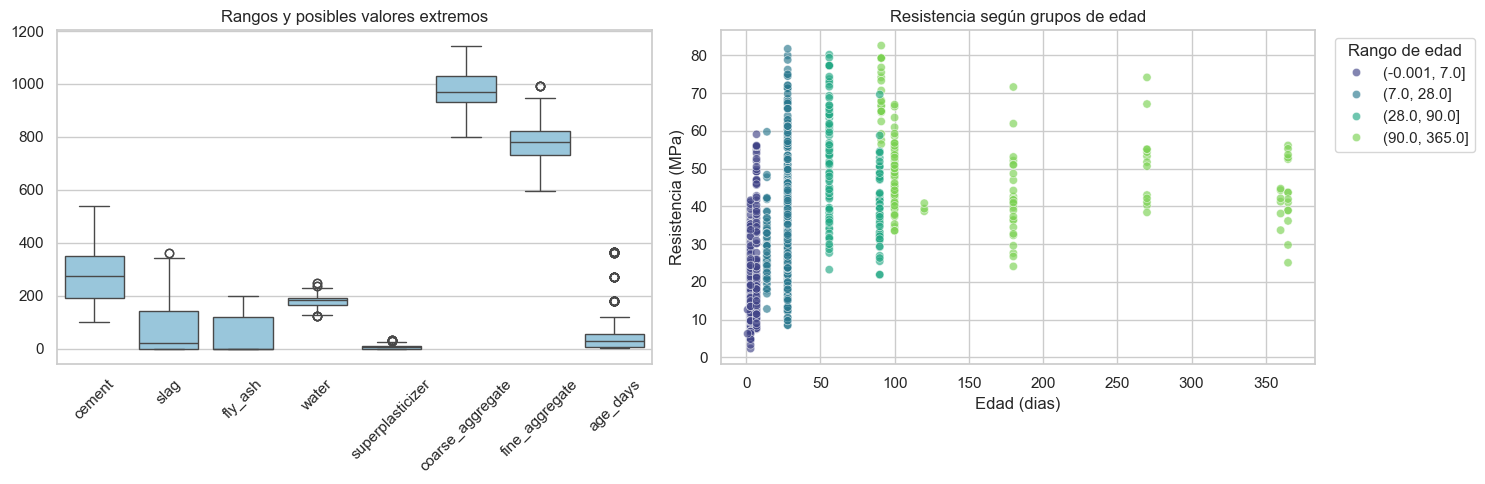

,count,mean,median,std
age_group,,,,
"(-0.001, 7.0]",262,22.31,18.52,12.85
"(7.0, 28.0]",487,35.73,33.30,14.33
"(28.0, 90.0]",145,47.64,46.64,13.93
"(90.0, 365.0]",136,49.55,47.34,12.94


In [5]:
quality_summary = pd.DataFrame({
    'tipo': df.dtypes.astype(str),
    'faltantes': df.isna().sum(),
    'unicos': df.nunique(),
    'asimetria': df.skew(numeric_only=True)
})
print('Registros duplicados:', df.duplicated().sum())
display(quality_summary)

q1 = df[predictor_cols + ['strength_mpa']].quantile(0.25)
q3 = df[predictor_cols + ['strength_mpa']].quantile(0.75)
iqr = q3 - q1
outlier_counts = ((df[predictor_cols + ['strength_mpa']] < (q1 - 1.5 * iqr)) | (df[predictor_cols + ['strength_mpa']] > (q3 + 1.5 * iqr))).sum()
display(outlier_counts.rename('posibles_valores_extremos').to_frame())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.boxplot(data=df[predictor_cols], ax=axes[0], color='#8ecae6')
axes[0].set_title('Rangos y posibles valores extremos')
axes[0].tick_params(axis='x', rotation=45)
sns.scatterplot(data=df, x='age_days', y='strength_mpa', hue=pd.cut(df['age_days'], bins=[0, 7, 28, 90, 365], include_lowest=True), palette='viridis', ax=axes[1], alpha=0.65)
axes[1].set_title('Resistencia según grupos de edad')
axes[1].set_xlabel('Edad (dias)')
axes[1].set_ylabel('Resistencia (MPa)')
axes[1].legend(title='Rango de edad', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

age_summary = df.assign(age_group=pd.cut(df['age_days'], bins=[0, 7, 28, 90, 365], include_lowest=True)).groupby('age_group', observed=True)['strength_mpa'].agg(['count', 'mean', 'median', 'std']).round(2)
display(age_summary)

### Hallazgos de los gráficos

- **Boxplots de componentes:** las escalas son muy diferentes entre variables y aparecen observaciones extremas, especialmente en edad y superplastificante. El criterio IQR detecta 59 posibles extremos en edad, pero no se eliminan automáticamente porque pueden representar ensayos reales de curado prolongado.
- **Resistencia por grupos de edad:** el aumento es marcado durante las primeras etapas del curado. La resistencia media pasa de 22,31 MPa hasta 7 días a 35,73 MPa entre 8 y 28 días, 47,64 MPa entre 29 y 90 días y 49,55 MPa después de 90 días. La ganancia posterior se desacelera, lo que apunta a una relación creciente pero no lineal.

## 3. Preparacion y modelos

Separamos un conjunto de prueba de forma aleatoria. La estandarizacion se coloca dentro de un pipeline para evitar fuga de informacion durante la validacion cruzada.

Modelos: regresion lineal, Random Forest y Gradient Boosting.

In [6]:
X = df.drop(columns='strength_mpa')
y = df['strength_mpa']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_STATE)

models = {
    'Regresion lineal': Pipeline([('scale', StandardScaler()), ('model', LinearRegression())]),
    'Random Forest': RandomForestRegressor(n_estimators=350, min_samples_leaf=2, random_state=RANDOM_STATE, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=300, learning_rate=0.04, max_depth=2, random_state=RANDOM_STATE)
}

results = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    results.append({'Modelo': name, 'MAE (MPa)': mean_absolute_error(y_test, pred), 'RMSE (MPa)': mean_squared_error(y_test, pred) ** 0.5, 'R2': r2_score(y_test, pred)})
results_df = pd.DataFrame(results).sort_values('RMSE (MPa)')
display(results_df.style.format({'MAE (MPa)':'{:.2f}', 'RMSE (MPa)':'{:.2f}', 'R2':'{:.3f}'}))

,Modelo,MAE (MPa),RMSE (MPa),R2
2,Gradient Boosting,4.38,5.58,0.879
1,Random Forest,4.02,5.67,0.875
0,Regresion lineal,7.75,9.80,0.628


## 4. Resultados obtenidos

Se entrenan tres modelos y se comparan mediante MAE, RMSE, R2 y validacion cruzada.

In [7]:
cv = KFold(n_splits=7, shuffle=True, random_state=RANDOM_STATE)
cv_rows = []
for name, model in models.items():
    scores = -cross_val_score(model, X, y, cv=cv, scoring='neg_root_mean_squared_error', n_jobs=1)
    cv_rows.append({'Modelo': name, 'RMSE CV promedio': scores.mean(), 'Desvio CV': scores.std()})
cv_results = pd.DataFrame(cv_rows).sort_values('RMSE CV promedio').reset_index(drop=True)
display(cv_results.style.format({'RMSE CV promedio':'{:.2f}', 'Desvio CV':'{:.2f}'}))

,Modelo,RMSE CV promedio,Desvio CV
0,Random Forest,5.00,0.47
1,Gradient Boosting,5.60,0.41
2,Regresion lineal,10.49,0.97


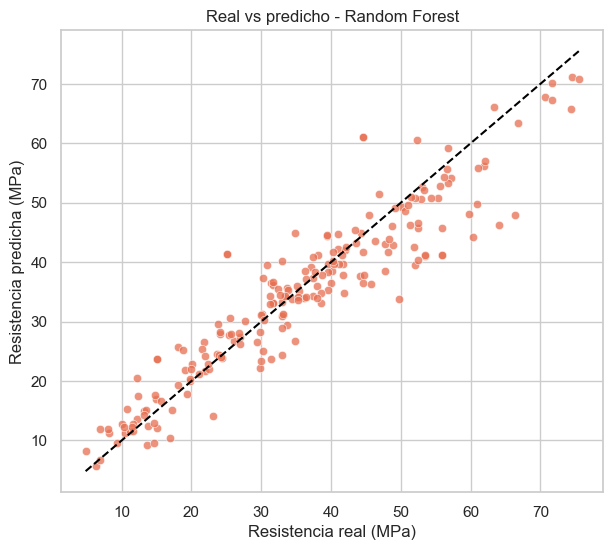

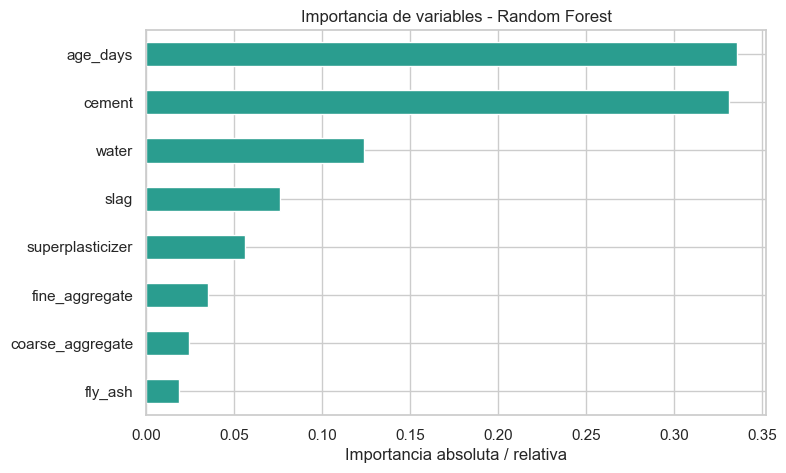

In [8]:
best_name = cv_results.iloc[0]['Modelo']
best_model = models[best_name]
best_pred = best_model.predict(X_test)
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=best_pred, color='#e76f51', alpha=0.75)
lims = [min(y_test.min(), best_pred.min()), max(y_test.max(), best_pred.max())]
plt.plot(lims, lims, '--', color='black')
plt.xlabel('Resistencia real (MPa)')
plt.ylabel('Resistencia predicha (MPa)')
plt.title(f'Real vs predicho - {best_name}')
plt.show()

if hasattr(best_model, 'feature_importances_'):
    importance = pd.Series(best_model.feature_importances_, index=X.columns).sort_values()
elif 'model' in best_model.named_steps and hasattr(best_model.named_steps['model'], 'coef_'):
    importance = pd.Series(abs(best_model.named_steps['model'].coef_), index=X.columns).sort_values()
else:
    importance = pd.Series(dtype=float)
if not importance.empty:
    importance.plot.barh(figsize=(8, 5), color='#2a9d8f', title=f'Importancia de variables - {best_name}')
    plt.xlabel('Importancia absoluta / relativa')
    plt.show()

### Hallazgos de los gráficos

- **Resistencia real frente a predicha:** el gráfico muestra Random Forest, seleccionado por su menor RMSE promedio con validación cruzada de 7 folds (5,01 MPa). En el conjunto de prueba alcanza RMSE de 5,67 MPa y R² de 0,875; la mayoría de los puntos queda cerca de la diagonal, aunque los errores aumentan en algunos valores extremos de resistencia.
- **Importancia de variables:** la edad y el cemento concentran la mayor capacidad explicativa del modelo, seguidos por variables vinculadas a la proporción de agua y aditivos. La importancia indica utilidad predictiva dentro del modelo, no un efecto causal aislado.

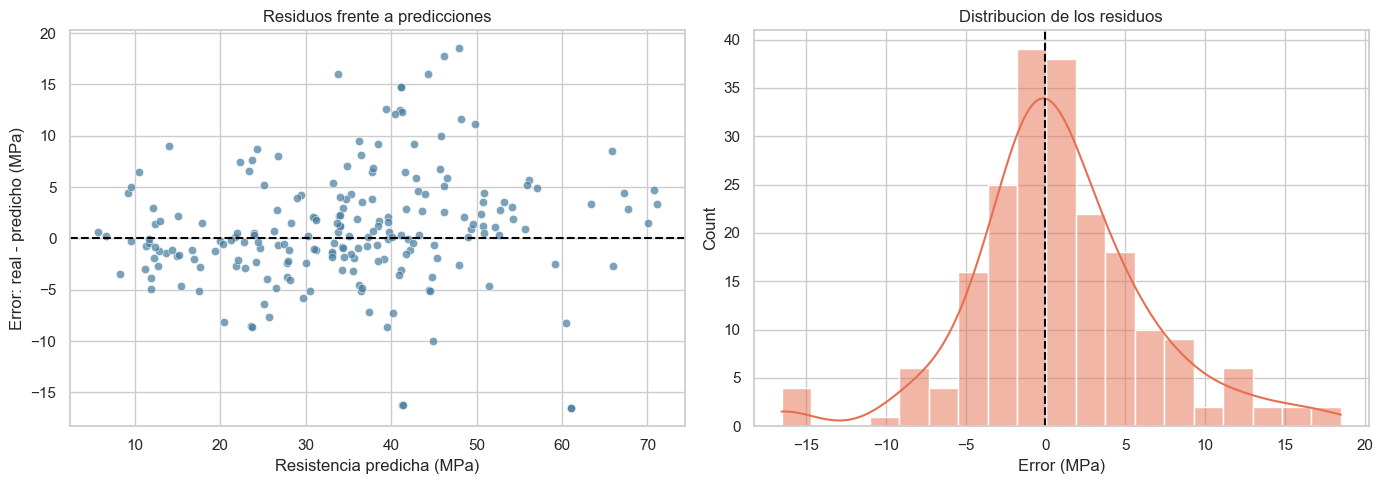

In [9]:
residuals = y_test - best_pred
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.scatterplot(x=best_pred, y=residuals, ax=axes[0], color='#457b9d', alpha=0.7)
axes[0].axhline(0, linestyle='--', color='black')
axes[0].set_title('Residuos frente a predicciones')
axes[0].set_xlabel('Resistencia predicha (MPa)')
axes[0].set_ylabel('Error: real - predicho (MPa)')
sns.histplot(residuals, kde=True, ax=axes[1], color='#e76f51')
axes[1].axvline(0, linestyle='--', color='black')
axes[1].set_title('Distribucion de los residuos')
axes[1].set_xlabel('Error (MPa)')
plt.tight_layout()
plt.show()

### Hallazgos de los gráficos

- **Residuos frente a predicciones:** los errores se distribuyen alrededor de cero, sin una tendencia lineal dominante. Sin embargo, se observan algunos errores grandes y una dispersión que no es completamente uniforme, señal de que ciertas mezclas son más difíciles de predecir.
- **Distribución de residuos:** la mayor parte de los errores se concentra cerca de cero, pero existen colas en ambos sentidos. El modelo ofrece un buen ajuste global, aunque todavía puede sobreestimar o subestimar de forma importante casos particulares.

## Metricas no aplicables

La precision es una métrica de clasificación y no corresponde a este ejercicio de regresión. Aquí se utilizan MAE, RMSE y R2 para evaluar el error de las predicciones continuas.

## 5.1. Robustez de la selección e interpretabilidad

La partición de prueba permite estimar el desempeño final, pero no debería utilizarse como único criterio de selección. Para comprobar que la ventaja no depende de una división afortunada, se utiliza validación cruzada de 7 folds repetida 3 veces, lo que genera 21 evaluaciones por modelo. Se comparan las distribuciones de RMSE y R² y se aplica la prueba de Friedman, adecuada para comparar tres modelos evaluados sobre exactamente las mismas particiones. También se usa Wilcoxon para contrastar los dos mejores.

,RMSE_promedio,RMSE_desvio,MAE_promedio,R2_promedio
Modelo,,,,
Random Forest,5.006,0.570,3.502,0.908
Gradient Boosting,5.566,0.563,4.242,0.887
Regresion lineal,10.465,0.703,8.314,0.601


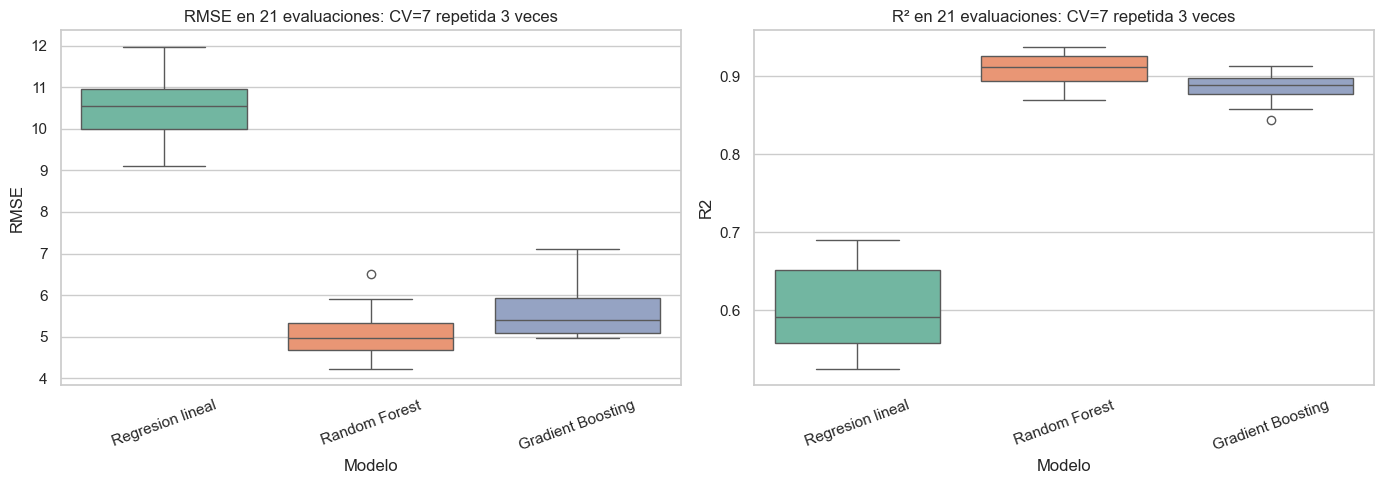

Friedman entre los tres modelos: estadístico=40.095, p=1.965e-09
Wilcoxon Random Forest vs Gradient Boosting: estadístico=2.000, p=2.861e-06


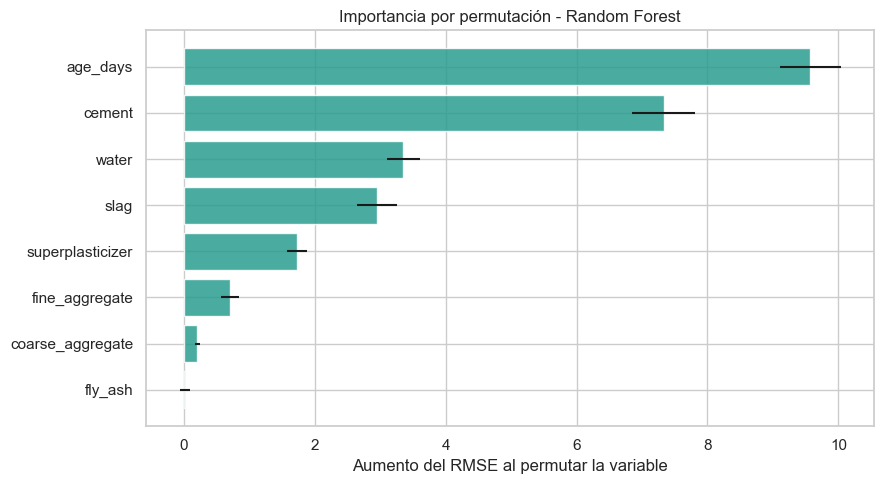

In [10]:
from sklearn.model_selection import RepeatedKFold, cross_validate
from sklearn.inspection import permutation_importance
from scipy.stats import friedmanchisquare, wilcoxon

repeated_cv = RepeatedKFold(n_splits=7, n_repeats=3, random_state=RANDOM_STATE)
regression_cv_rows = []
for name, model in models.items():
    scores = cross_validate(
        model, X, y, cv=repeated_cv,
        scoring={'rmse': 'neg_root_mean_squared_error', 'mae': 'neg_mean_absolute_error', 'r2': 'r2'},
        n_jobs=1
    )
    for fold, (rmse, mae, r2) in enumerate(zip(-scores['test_rmse'], -scores['test_mae'], scores['test_r2']), start=1):
        regression_cv_rows.append({'Modelo': name, 'Particion': fold, 'RMSE': rmse, 'MAE': mae, 'R2': r2})
regression_cv_detail = pd.DataFrame(regression_cv_rows)
regression_cv_summary = regression_cv_detail.groupby('Modelo').agg(
    RMSE_promedio=('RMSE', 'mean'), RMSE_desvio=('RMSE', 'std'),
    MAE_promedio=('MAE', 'mean'), R2_promedio=('R2', 'mean')
).sort_values('RMSE_promedio')
display(regression_cv_summary.style.format('{:.3f}'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=regression_cv_detail, x='Modelo', y='RMSE', hue='Modelo', legend=False, ax=axes[0], palette='Set2')
axes[0].set_title('RMSE en 21 evaluaciones: CV=7 repetida 3 veces')
axes[0].tick_params(axis='x', rotation=20)
sns.boxplot(data=regression_cv_detail, x='Modelo', y='R2', hue='Modelo', legend=False, ax=axes[1], palette='Set2')
axes[1].set_title('R² en 21 evaluaciones: CV=7 repetida 3 veces')
axes[1].tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

wide_rmse = regression_cv_detail.pivot(index='Particion', columns='Modelo', values='RMSE')
friedman_stat, friedman_p = friedmanchisquare(*[wide_rmse[column] for column in wide_rmse.columns])
ranked_models = regression_cv_summary.index.tolist()
wilcoxon_stat, wilcoxon_p = wilcoxon(wide_rmse[ranked_models[0]], wide_rmse[ranked_models[1]])
print(f'Friedman entre los tres modelos: estadístico={friedman_stat:.3f}, p={friedman_p:.4g}')
print(f'Wilcoxon {ranked_models[0]} vs {ranked_models[1]}: estadístico={wilcoxon_stat:.3f}, p={wilcoxon_p:.4g}')

selected_regressor_name = ranked_models[0]
selected_regressor = models[selected_regressor_name]
selected_regressor.fit(X_train, y_train)
perm = permutation_importance(selected_regressor, X_test, y_test, scoring='neg_root_mean_squared_error', n_repeats=15, random_state=RANDOM_STATE, n_jobs=-1)
permutation_df = pd.DataFrame({'Variable': X.columns, 'Aumento_RMSE': perm.importances_mean, 'Desvio': perm.importances_std}).sort_values('Aumento_RMSE')
plt.figure(figsize=(9, 5))
plt.barh(permutation_df['Variable'], permutation_df['Aumento_RMSE'], xerr=permutation_df['Desvio'], color='#2a9d8f', alpha=0.85)
plt.xlabel('Aumento del RMSE al permutar la variable')
plt.title(f'Importancia por permutación - {selected_regressor_name}')
plt.tight_layout()
plt.show()

### Conclusión de la comparación

- **Regresión lineal queda descartada** porque sus errores son claramente mayores y no representa bien la relación no lineal entre edad, proporciones de materiales y resistencia.
- **Gradient Boosting logra el menor RMSE en la única partición de prueba**, pero Random Forest obtiene el menor RMSE promedio en validación cruzada. Cuando dos modelos están próximos, se prioriza la evidencia repetida sobre una sola partición.
- **Selección final:** Random Forest es la opción más defendible por su desempeño promedio y estabilidad. Gradient Boosting sigue siendo una alternativa competitiva; la prueba de Wilcoxon indica si la diferencia observada es suficientemente consistente para hablar de una superioridad estadística.
- **Explicación a stakeholders:** la importancia por permutación expresa cuánto empeora el error al desordenar cada variable. Es más intuitiva que la importancia interna de los árboles y permite explicar qué información sostiene las predicciones, sin confundir importancia predictiva con causalidad.

El modelo debe emplearse para priorizar formulaciones o detectar ensayos que merecen atención. No reemplaza las pruebas físicas ni los criterios de seguridad de ingeniería.

## 5. Interpretacion de resultados

El grafico real vs. predicho, los residuos y la importancia de variables permiten interpretar el comportamiento del modelo seleccionado.

## 6. Justificacion de la seleccion de algoritmos e interpretacion

### Objetivo del modelado

El modelo recibe las cantidades de los materiales y la edad del hormigon. Luego entrega una estimacion de resistencia en MPa. Por ejemplo, si una mezcla tiene mas cemento o una edad diferente, el modelo puede aprender que la resistencia esperada tambien cambia.

### Criterio para seleccionar los algoritmos

Se comparan tres enfoques con distintos niveles de complejidad. La regresion lineal funciona como referencia simple e interpretable. Random Forest y Gradient Boosting permiten representar relaciones no lineales entre los componentes de la mezcla y la resistencia. Esta comparacion permite determinar si la complejidad adicional mejora las predicciones de forma consistente.

**Regresion lineal.** Intenta explicar la resistencia sumando el efecto de cada ingrediente. Cada variable aporta una cantidad positiva o negativa a la prediccion. Es facil de explicar, pero puede quedarse corta cuando la relacion entre los ingredientes no es una linea recta.

**Random Forest.** Construye muchos arboles de decision. Cada arbol hace preguntas del tipo “¿la edad es mayor que cierto valor?” o “¿el cemento esta por encima de cierto nivel?”. Luego combina las respuestas de todos los arboles. Suele funcionar bien con relaciones complejas y es menos sensible a valores extremos, aunque es menos facil de explicar como una unica regla.

**Gradient Boosting.** Construye los arboles de forma secuencial. Cada arbol nuevo intenta corregir los errores que cometieron los anteriores. Esto permite capturar patrones sutiles, pero requiere controlar la complejidad para no aprender demasiado los datos historicos.

### Criterios de evaluacion

- **MAE:** error absoluto promedio. Un MAE de 5 significa que, en promedio, la prediccion se aleja 5 MPa de la resistencia real.
- **RMSE:** parecido al MAE, pero castiga mas los errores grandes. Por eso es especialmente util si una prediccion muy equivocada puede ser relevante.
- **R2:** indica cuanto de la variacion de la resistencia logra explicar el modelo. Cuanto mas cerca de 1, mejor; un valor cercano a 0 significa que explica poco mas que usar el promedio.
- **Validacion cruzada:** repite el entrenamiento y la evaluacion con distintas particiones. Sirve para comprobar que el resultado no depende solamente de una division afortunada de los datos.

### Interpretacion de resultados

En el grafico “real vs. predicho”, los puntos cercanos a la diagonal representan buenas predicciones. Los puntos alejados muestran mezclas dificiles de estimar. La grafica de importancia ayuda a identificar que variables fueron mas utiles para el modelo, pero no demuestra por si sola que una variable cause la resistencia.

**Decision final:** se recomienda el modelo que combine menor RMSE en el conjunto de prueba, buen R2 y un resultado estable en validacion cruzada. La prediccion sirve como apoyo al analisis, no reemplaza los ensayos de laboratorio ni la revision de un profesional.

## 7. Conclusiones finales

Los resultados de regresión son **muy buenos**. Random Forest es el modelo más sólido: en la validación cruzada de 7 folds repetida tres veces alcanza un R² promedio de 0,908, un RMSE promedio de 5,01 MPa y un MAE promedio de 3,50 MPa. Esto significa que explica aproximadamente el 91 % de la variación de la resistencia y que su error absoluto típico se encuentra alrededor de 3,5 MPa.

Gradient Boosting también presenta un desempeño competitivo, con R² promedio de 0,887 y RMSE de 5,57 MPa. La regresión lineal queda claramente por debajo, con R² de 0,601 y RMSE de 10,47 MPa, lo que confirma que la relación entre los componentes, la edad y la resistencia no se representa adecuadamente mediante una función puramente lineal.

Las pruebas estadísticas respaldan la selección. Friedman produce un valor p inferior a 0,000001 y la comparación de Wilcoxon entre Random Forest y Gradient Boosting también resulta significativa, con p inferior a 0,00001. Por lo tanto, la ventaja de Random Forest no parece depender de una única partición favorable.

**Conclusión del ejercicio:** Random Forest es el modelo recomendado por su precisión, estabilidad y capacidad para representar relaciones no lineales. La importancia por permutación ayuda a explicar a los stakeholders qué variables sostienen las predicciones. El modelo puede utilizarse para priorizar formulaciones o identificar ensayos que requieren atención, pero no sustituye las pruebas físicas de laboratorio ni los criterios de seguridad de ingeniería.